# Ginzburg–Landau Free Energy Functional

The **Ginzburg–Landau (GL)** theory is a phenomenological framework that describes
superconductivity near the critical temperature $T_c$ through a complex order
parameter $\psi(\mathbf{r})$. Its power lies in capturing spatially inhomogeneous
phenomena — vortices, domain walls, surface superconductivity — without requiring
a full microscopic solution.

## The Order Parameter

The superconducting state is described by a complex scalar field
$\psi(\mathbf{r}) = |\psi|\, e^{i\varphi}$, where:

- $|\psi(\mathbf{r})|^2$ is proportional to the superfluid density $n_s$
- $\varphi(\mathbf{r})$ is the macroscopic quantum phase
- The supercurrent is $\mathbf{J}_s \propto |\psi|^2 \nabla\varphi$

Near $T_c$, $|\psi|$ is small and the free energy can be expanded as a
power series — this is the Landau expansion.

## Free Energy Functional

The GL free energy density (in Gaussian units) is:

$$
f_s - f_n = \alpha\, |\psi|^2 + \frac{\beta}{2}\, |\psi|^4
+ \frac{1}{2m^*} \left| \left( -i\hbar\nabla - \frac{2e}{c}\mathbf{A} \right) \psi \right|^2
+ \frac{|\mathbf{B}|^2}{8\pi}
$$

The four terms represent:

| Term | Physical meaning |
|------|------------------|
| $\alpha \|\psi\|^2$ | Condensation energy; $\alpha < 0$ below $T_c$ |
| $\frac{\beta}{2}\|\psi\|^4$ | Stabilization (prevents $\|\psi\| \to \infty$) |
| Gradient term | Kinetic energy of supercurrents |
| $\|\mathbf{B}\|^2 / 8\pi$ | Magnetic field energy |

The temperature dependence enters through $\alpha(T) = \alpha_0 (T - T_c) / T_c$,
which changes sign at $T_c$.

## GL Equations

Minimizing the free energy functional $F = \int f\, d^3r$ with respect to
$\psi^*$ and $\mathbf{A}$ yields two coupled PDEs.

### First GL Equation (order parameter)

$$
\alpha\,\psi + \beta\,|\psi|^2 \psi
+ \frac{1}{2m^*} \left( -i\hbar\nabla - \frac{2e}{c}\mathbf{A} \right)^{\!2} \psi = 0
$$

This is a nonlinear Schrödinger equation for the order parameter.

### Second GL Equation (supercurrent)

$$
\mathbf{J}_s = \frac{e^*}{m^*} \operatorname{Re}\!\left[
\psi^* \left( -i\hbar\nabla - \frac{2e}{c}\mathbf{A} \right) \psi
\right]
$$

Combined with Maxwell's equation $\nabla \times \mathbf{B} = \frac{4\pi}{c}\mathbf{J}_s$,
this yields the Meissner screening.

## Characteristic Lengths

Two fundamental length scales emerge from GL theory:

**Coherence length** (scale over which $\psi$ varies):
$$
\xi_{\text{GL}}(T) = \sqrt{\frac{\hbar^2}{2m^* |\alpha(T)|}}
= \frac{\xi_{\text{GL}}(0)}{\sqrt{1 - T/T_c}}
$$

**Penetration depth** (scale over which $\mathbf{B}$ decays):
$$
\lambda_{\text{GL}}(T) = \sqrt{\frac{m^* c^2 \beta}{16\pi e^2 |\alpha(T)|}}
= \frac{\lambda_{\text{GL}}(0)}{\sqrt{1 - T/T_c}}
$$

Their ratio defines the **GL parameter**:
$$
\kappa = \frac{\lambda}{\xi}
$$

- $\kappa < 1/\sqrt{2}$: Type-I superconductor (positive surface energy)
- $\kappa > 1/\sqrt{2}$: Type-II superconductor (vortices are energetically favorable)

In [1]:
import numpy as np

# GL parameters for common superconductors
materials = {
    "Nb":  {"Tc": 9.2, "xi0": 38.0, "lambda0": 39.0},   # nm
    "NbN": {"Tc": 16.0, "xi0": 5.0, "lambda0": 200.0},
    "Al":  {"Tc": 1.2, "xi0": 1600.0, "lambda0": 16.0},
    "Pb":  {"Tc": 7.2, "xi0": 83.0, "lambda0": 37.0},
}

print(f"{'Material':>8}  {'Tc (K)':>7}  {'ξ₀ (nm)':>9}  {'λ₀ (nm)':>9}  {'κ':>6}  {'Type':>7}")
print("-" * 58)
for name, p in materials.items():
    kappa = p["lambda0"] / p["xi0"]
    sc_type = "II" if kappa > 1/np.sqrt(2) else "I"
    print(f"{name:>8}  {p['Tc']:7.1f}  {p['xi0']:9.1f}  {p['lambda0']:9.1f}  {kappa:6.2f}  {'Type-'+sc_type:>7}")

Material   Tc (K)    ξ₀ (nm)    λ₀ (nm)       κ     Type
----------------------------------------------------------
      Nb      9.2       38.0       39.0    1.03  Type-II
     NbN     16.0        5.0      200.0   40.00  Type-II
      Al      1.2     1600.0       16.0    0.01   Type-I
      Pb      7.2       83.0       37.0    0.45   Type-I


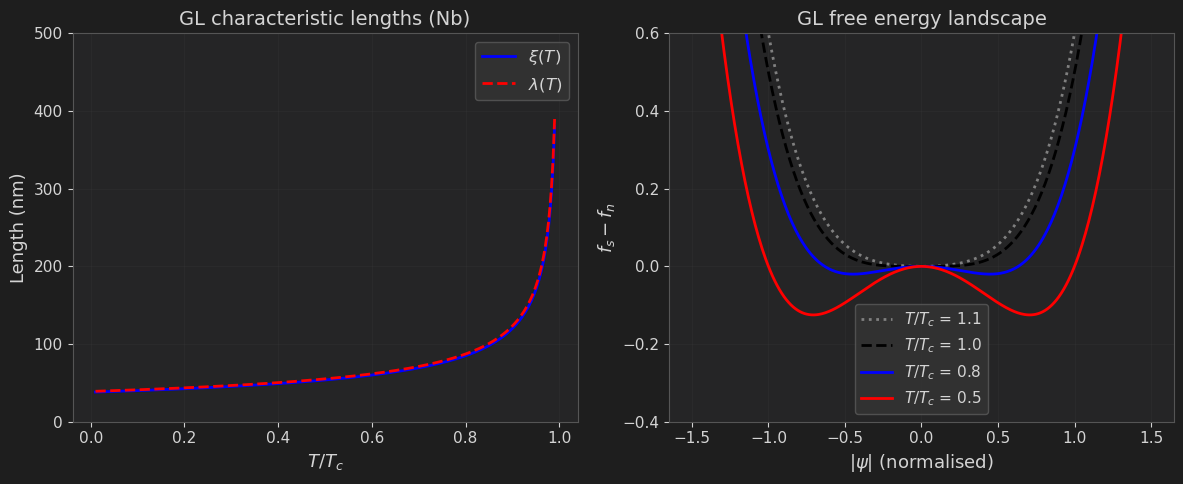

In [3]:
# Temperature-dependent GL length scales
import numpy as np
import matplotlib.pyplot as plt

import supermag
supermag.apply_theme("dark")

T_over_Tc = np.linspace(0.01, 0.99, 300)

# Nb parameters
xi0 = 38.0    # nm
lam0 = 39.0   # nm
kappa = lam0 / xi0

xi_T = xi0 / np.sqrt(1 - T_over_Tc)
lam_T = lam0 / np.sqrt(1 - T_over_Tc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: length scales
axes[0].plot(T_over_Tc, xi_T, 'b-', lw=2, label=r'$\xi(T)$')
axes[0].plot(T_over_Tc, lam_T, 'r--', lw=2, label=r'$\lambda(T)$')
axes[0].set_xlabel(r'$T / T_c$', fontsize=13)
axes[0].set_ylabel('Length (nm)', fontsize=13)
axes[0].set_title('GL characteristic lengths (Nb)', fontsize=14)
axes[0].set_ylim(0, 500)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Right: GL free energy landscape
psi = np.linspace(-1.5, 1.5, 400)
for T_frac, col, ls in [(1.1, 'grey', ':'), (1.0, 'k', '--'),
                          (0.8, 'blue', '-'), (0.5, 'red', '-')]:
    alpha_val = T_frac - 1.0   # α ∝ (T - Tc)/Tc
    f = alpha_val * psi**2 + 0.5 * psi**4
    axes[1].plot(psi, f, color=col, ls=ls, lw=2,
                 label=rf'$T/T_c$ = {T_frac}')

axes[1].set_xlabel(r'$|\psi|$ (normalised)', fontsize=13)
axes[1].set_ylabel(r'$f_s - f_n$', fontsize=13)
axes[1].set_title('GL free energy landscape', fontsize=14)
axes[1].set_ylim(-0.4, 0.6)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

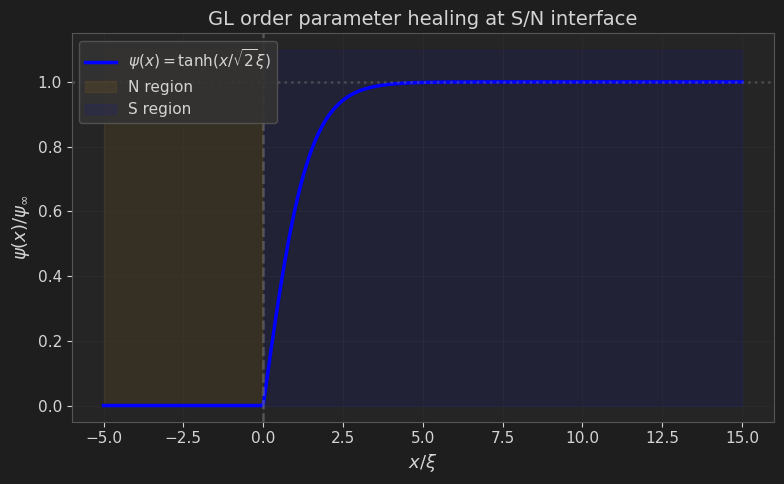

In [4]:
# 1D GL order parameter healing at an S/N interface
import numpy as np
import matplotlib.pyplot as plt

# Normalised 1st GL equation (no magnetic field, 1D):
# ξ² ψ'' - ψ + ψ³ = 0
# Analytic solution at S/N boundary: ψ(x) = tanh(x / (√2 ξ))

x = np.linspace(-5, 15, 500)  # in units of ξ

fig, ax = plt.subplots(figsize=(8, 5))

# Exact GL healing profile
psi_exact = np.tanh(x / np.sqrt(2))
psi_exact[x < 0] = 0  # N side: no pairing

ax.plot(x, psi_exact, 'b-', lw=2.5, label=r'$\psi(x) = \tanh(x/\sqrt{2}\xi)$')
ax.fill_between(x, 0, 1.1, where=(x < 0), alpha=0.08, color='orange', label='N region')
ax.fill_between(x, 0, 1.1, where=(x >= 0), alpha=0.08, color='blue', label='S region')
ax.axvline(0, ls='--', color='grey', alpha=0.5)
ax.axhline(1, ls=':', color='grey', alpha=0.4)

ax.set_xlabel(r'$x / \xi$', fontsize=13)
ax.set_ylabel(r'$\psi(x) / \psi_\infty$', fontsize=13)
ax.set_title('GL order parameter healing at S/N interface', fontsize=14)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## SUPERMag GL Solver

The `supermag.ginzburg_landau.minimize()` function implements the same TDGL
relaxation on a 2D grid via the C++ composable path.  Below we compute the
equilibrium order parameter for Nb-like parameters near $T_c$ and visualise
the spatial structure.

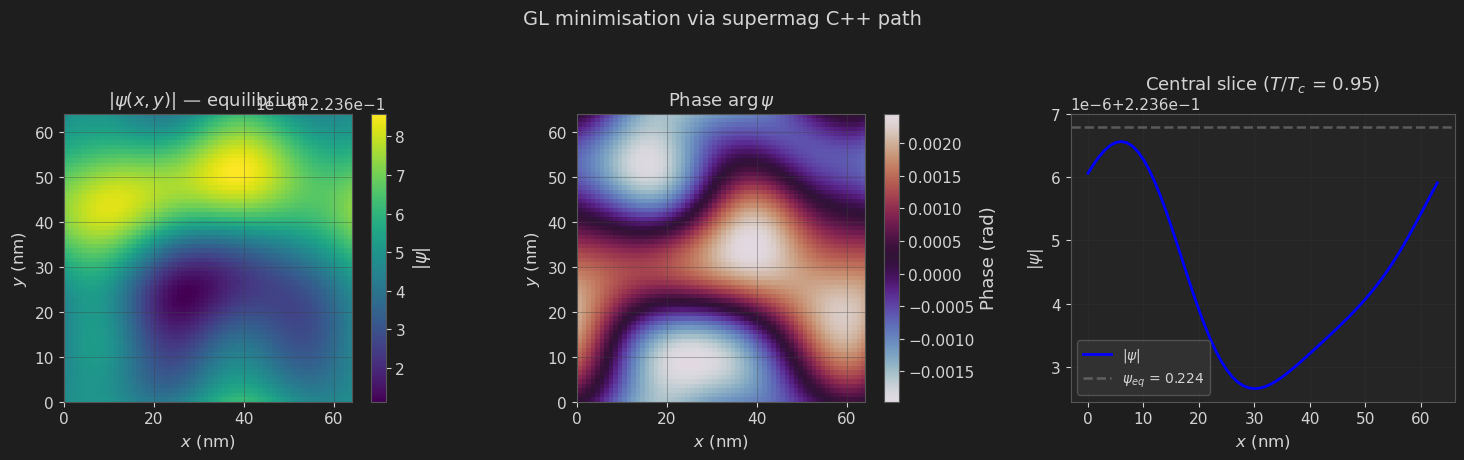

Grid: 64×64, dx = 1.0 nm
Mean |ψ| = 0.2236, expected ψ_eq = 0.2236


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import supermag

# GL parameters for Nb at T/Tc = 0.95
T_over_Tc = 0.95
alpha = -(1 - T_over_Tc)   # α < 0 below Tc
beta  = 1.0                # normalised
kappa = 39.0 / 38.0        # λ/ξ for Nb

nx, ny = 64, 64
dx = 1.0  # nm

# Minimise GL free energy via the C++ composable path
psi = supermag.ginzburg_landau.minimize(alpha, beta, kappa, nx, ny, dx)

# --- Visualise ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 2D amplitude
im0 = axes[0].imshow(np.abs(psi), cmap='viridis', origin='lower',
                      extent=[0, nx*dx, 0, ny*dx])
axes[0].set_xlabel('$x$ (nm)', fontsize=12)
axes[0].set_ylabel('$y$ (nm)', fontsize=12)
axes[0].set_title(r'$|\psi(x,y)|$ — equilibrium', fontsize=13)
plt.colorbar(im0, ax=axes[0], label=r'$|\psi|$')

# 2D phase
im1 = axes[1].imshow(np.angle(psi), cmap='twilight', origin='lower',
                      extent=[0, nx*dx, 0, ny*dx])
axes[1].set_xlabel('$x$ (nm)', fontsize=12)
axes[1].set_ylabel('$y$ (nm)', fontsize=12)
axes[1].set_title(r'Phase $\arg\psi$', fontsize=13)
plt.colorbar(im1, ax=axes[1], label='Phase (rad)')

# 1D slice through centre
mid = ny // 2
axes[2].plot(np.arange(nx) * dx, np.abs(psi[mid, :]), 'b-', lw=2, label=r'$|\psi|$')
psi_eq = np.sqrt(max(-alpha / beta, 0.0))
axes[2].axhline(psi_eq, ls='--', color='grey', alpha=0.6, label=rf'$\psi_{{eq}}$ = {psi_eq:.3f}')
axes[2].set_xlabel('$x$ (nm)', fontsize=12)
axes[2].set_ylabel(r'$|\psi|$', fontsize=12)
axes[2].set_title(f'Central slice ($T/T_c$ = {T_over_Tc})', fontsize=13)
axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.3)

fig.suptitle('GL minimisation via supermag C++ path', fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

print(f"Grid: {nx}×{ny}, dx = {dx} nm")
print(f"Mean |ψ| = {np.mean(np.abs(psi)):.4f}, expected ψ_eq = {psi_eq:.4f}")

## Connection to BCS Theory

Gor'kov showed that GL theory can be derived microscopically from BCS theory
near $T_c$. The GL coefficients are related to microscopic parameters:

$$
\alpha = N(0) \frac{T - T_c}{T_c}, \qquad
\beta = \frac{7\zeta(3)}{8\pi^2} \frac{N(0)}{(k_B T_c)^2}
$$

where $N(0)$ is the density of states at the Fermi energy and
$\zeta(3) \approx 1.202$ is the Riemann zeta function.

## References

1. Ginzburg, V.L. & Landau, L.D., "On the theory of superconductivity," Zh. Eksp. Teor. Fiz. **20**, 1064 (1950).
2. Gor'kov, L.P., "Microscopic derivation of the Ginzburg–Landau equations in the theory of superconductivity," Sov. Phys. JETP **9**, 1364 (1959).
3. Tinkham, M., *Introduction to Superconductivity*, 2nd ed. (Dover, 1996).